In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
df=pd.read_csv("twitter_training.csv")

In [3]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
df.columns = ['ID', 'Topic', 'Sentiment', 'Tweet']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74681 non-null  int64 
 1   Topic      74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
df = df.dropna(subset=['Tweet'])


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove links
    text = re.sub(r"[^a-z\s]", "", text)     # remove punctuation
    return text

df['clean_tweet'] = df['Tweet'].apply(clean_text)


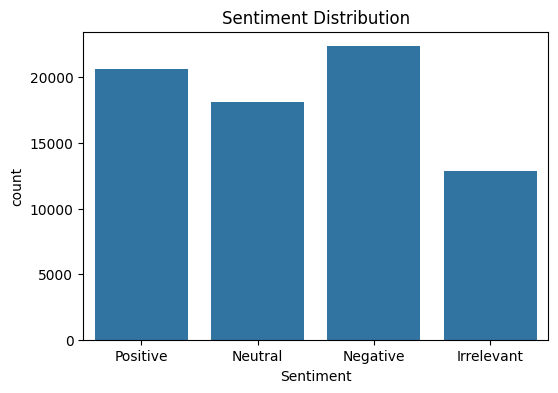

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


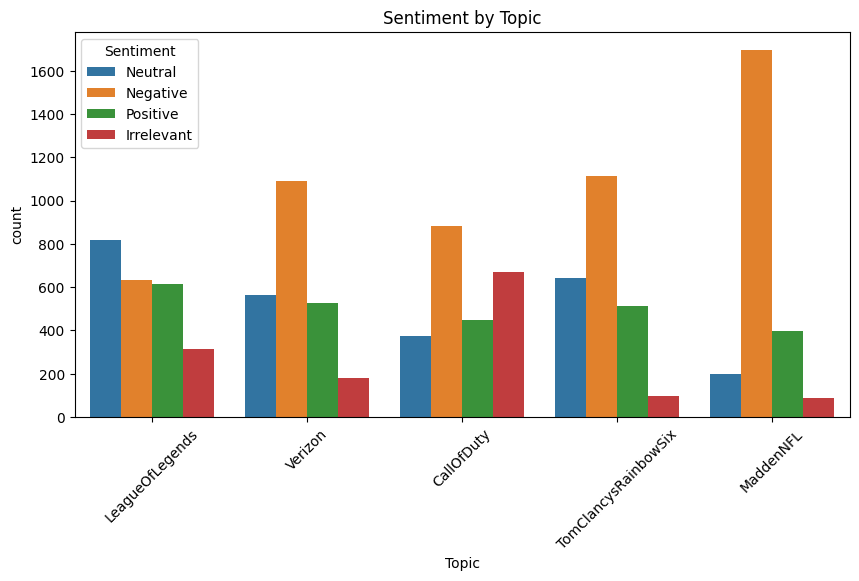

In [9]:
top_topics = df['Topic'].value_counts().head(5).index

plt.figure(figsize=(10,5))
sns.countplot(
    data=df[df['Topic'].isin(top_topics)],
    x='Topic',
    hue='Sentiment'
)
plt.title("Sentiment by Topic")
plt.xticks(rotation=45)
plt.show()


In [10]:
X = df['clean_tweet']
y = df['Sentiment']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.25, random_state=42
)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
